In [1]:
pip install wfdb tensorflow scikit-learn imbalanced-learn numpy pandas matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 30.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# §0  IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
# Standard library
import os
import csv
import warnings
warnings.filterwarnings("ignore")           # suppress noisy deprecation logs

# Numerical / scientific
import numpy as np                          # array math
import pandas as pd                         # tabular helpers

# ECG-specific I/O
import wfdb                                 # PhysioNet WFDB format reader

# Machine-learning / deep-learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from imblearn.over_sampling import SMOTE    # Synthetic Minority Over-sampling

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility — fix every random seed so results are deterministic
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPUs available    :", tf.config.list_physical_devices("GPU"))


# ─────────────────────────────────────────────────────────────────────────────
# §1  CONFIGURATION  — change these without touching the rest of the script
# ─────────────────────────────────────────────────────────────────────────────
# MIT-BIH record numbers (48 recordings in total; use all or a subset)
MIT_BIH_RECORDS = [
    "100","101","102","103","104","105","106","107","108","109",
    "111","112","113","114","115","116","117","118","119","121",
    "122","123","124","200","201","202","203","205","207","208",
    "209","210","212","213","214","215","217","219","220","221",
    "222","223","228","230","231","232","233","234",
]

# Where wfdb will cache / look for the records
# Pass db_dir=None and download=True to stream from PhysioNet automatically,
# OR set db_dir to a local folder if you have already downloaded the dataset.
DB_DIR    = None          # e.g. r"C:\data\mitdb"  — set to None to auto-download
DOWNLOAD  = True          # set False if files already present in DB_DIR

# Beat segmentation window
WINDOW_BEFORE = 90        # samples before the R-peak
WINDOW_AFTER  = 90        # samples after  the R-peak
# → total window length = WINDOW_BEFORE + WINDOW_AFTER = 180 samples

# Label mapping
#   Normal beat  → class 0
#   Abnormal beat→ class 1
NORMAL_LABELS   = {"N"}              # Normal sinus rhythm
ABNORMAL_LABELS = {"L","R","V","A"}  # LBBB, RBBB, PVC, APB
KEEP_LABELS     = NORMAL_LABELS | ABNORMAL_LABELS

# Training hyper-parameters
BATCH_SIZE = 64
EPOCHS     = 30
LR         = 1e-3         # Adam learning rate

# Quantisation
Q_BITS    = 8             # target bit-width (INT8 → range −128 … 127)
Q_MAX_INT = 2 ** (Q_BITS - 1) - 1   # 127

# Output directory for exported files (weights CSV, C header, test window)
OUT_DIR = r"C:\Users\rishi\OneDrive\Desktop\mitbihcnn\fpga_export"
os.makedirs(OUT_DIR, exist_ok=True)

TensorFlow version: 2.19.0
GPUs available    : []


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# §2  DATA LOADING & BEAT SEGMENTATION
# ─────────────────────────────────────────────────────────────────────────────
def load_mitbih(records, db_dir=None, download=True):
    """
    Reads every MIT-BIH record and extracts labelled beat windows.

    Parameters
    ----------
    records  : list[str]   – record IDs, e.g. ["100", "101", …]
    db_dir   : str | None  – local directory; None → stream from PhysioNet
    download : bool        – ignored when db_dir is not None

    Returns
    -------
    X : np.ndarray, shape (n_beats, 180, 1)  – normalised ECG windows
    y : np.ndarray, shape (n_beats,)         – binary labels (0=N, 1=Abnormal)
    """
    all_windows = []   # will collect (180,) float arrays
    all_labels  = []   # matching integer label

    for rec_id in records:
        try:
            # ── 2-a  Load the raw ECG signal ──────────────────────────────
            # wfdb.rdrecord returns a Record object.
            # .p_signal is shape (n_samples, n_channels); we take channel 0 (MLII).
            # PhysioNet sampling rate for MIT-BIH is 360 Hz.
            if db_dir:
                record = wfdb.rdrecord(os.path.join(db_dir, rec_id))
                annot  = wfdb.rdann  (os.path.join(db_dir, rec_id), "atr")
            else:
                record = wfdb.rdrecord(rec_id, pn_dir="mitdb")
                annot  = wfdb.rdann  (rec_id, "atr", pn_dir="mitdb")

            signal = record.p_signal[:, 0]   # shape: (n_samples,)  — lead MLII

            # ── 2-b  Iterate over annotated R-peaks ───────────────────────
            # annot.sample  → array of sample indices where each beat occurs
            # annot.symbol  → corresponding AAMI beat label  (N, V, L, …)
            for sample_idx, symbol in zip(annot.sample, annot.symbol):
                if symbol not in KEEP_LABELS:
                    continue  # skip pacemaker, noise, junction beats, etc.

                # ── 2-c  Extract 180-sample window ────────────────────────
                # start / end are the array slice boundaries.
                # We guard against going out of bounds (first/last beats).
                start = sample_idx - WINDOW_BEFORE   # inclusive
                end   = sample_idx + WINDOW_AFTER    # exclusive (Python slicing)

                if start < 0 or end > len(signal):
                    continue   # skip beats too close to the recording edge

                window = signal[start:end]           # shape: (180,)

                # ── 2-d  Z-score normalisation ────────────────────────────
                # Formula:  z = (x − μ) / σ
                # Purpose:  removes DC offset (baseline wander) and scales
                #           each beat to unit variance so CNN inputs are
                #           consistently in roughly the [−3, +3] range —
                #           important for stable gradient descent and for
                #           ensuring the quantisation scale is meaningful.
                mu    = window.mean()
                sigma = window.std() + 1e-8          # +eps avoids division by zero
                window = (window - mu) / sigma

                # ── 2-e  Binary label assignment ──────────────────────────
                label = 0 if symbol in NORMAL_LABELS else 1

                all_windows.append(window)
                all_labels.append(label)

        except Exception as exc:
            print(f"  [SKIP] record {rec_id}: {exc}")

    # Stack into arrays
    X = np.array(all_windows, dtype=np.float32)   # (N, 180)
    y = np.array(all_labels,  dtype=np.int32)     # (N,)

    # ── 2-f  Add channel dimension expected by Conv1D ─────────────────────
    # Keras Conv1D input shape: (batch, timesteps, channels)
    # Our signal has 1 channel (single ECG lead) → reshape to (N, 180, 1).
    X = X[..., np.newaxis]                         # (N, 180, 1)

    print(f"\nLoaded {len(X)} beats  |  Normal={np.sum(y==0)}  Abnormal={np.sum(y==1)}")
    return X, y


print("\n" + "="*60)
print("STEP 1 — Loading MIT-BIH data …")
print("="*60)
X, y = load_mitbih(MIT_BIH_RECORDS, db_dir=DB_DIR, download=DOWNLOAD)



STEP 1 — Loading MIT-BIH data …

Loaded 100038 beats  |  Normal=75033  Abnormal=25005


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# §3  TRAIN / VALIDATION / TEST SPLIT
# ─────────────────────────────────────────────────────────────────────────────
# Stratified split → preserves the class ratio in every partition.
# 70% train  |  15% validation  |  15% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1765,   # 0.15 / 0.85 ≈ 0.1765
    random_state=SEED, stratify=y_trainval
)

print(f"\nSplit → Train:{len(X_train)}  Val:{len(X_val)}  Test:{len(X_test)}")



Split → Train:70023  Val:15009  Test:15006


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# §4  CLASS IMBALANCE — SMOTE
# ─────────────────────────────────────────────────────────────────────────────
# MIT-BIH is heavily imbalanced: ~75–80% Normal beats.
# Without correction the model learns "always predict Normal" and still gets
# ~75% accuracy — useless for detecting arrhythmias.
#
# SMOTE (Synthetic Minority Over-sampling TEchnique):
#   For each minority sample, kNN neighbours are found in feature space and
#   synthetic samples are interpolated between the original and its neighbours.
#   Result: a balanced training set WITHOUT simply duplicating minority beats.
#
# SMOTE works on 2-D arrays → we flatten (180,1) → (180,) for SMOTE,
# then reshape back afterwards.
print("\nSTEP 2 — Applying SMOTE to balance training set …")

X_train_2d = X_train.reshape(len(X_train), -1)   # (n, 180)
smote      = SMOTE(random_state=SEED, k_neighbors=5)
X_res_2d, y_res = smote.fit_resample(X_train_2d, y_train)
X_res = X_res_2d[..., np.newaxis]                 # (n_balanced, 180, 1)

print(f"After SMOTE → Train:{len(X_res)}  (Normal={np.sum(y_res==0)}  Abnormal={np.sum(y_res==1)})")



STEP 2 — Applying SMOTE to balance training set …
After SMOTE → Train:105042  (Normal=52521  Abnormal=52521)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# §5  MODEL ARCHITECTURE — FPGA-FRIENDLY SHALLOW 1-D CNN
# ─────────────────────────────────────────────────────────────────────────────
"""
FPGA design decisions explained:

┌─────────────────────────────────────────────────────────────────┐
│  Layer                │  Why chosen for FPGA                    │
├─────────────────────────────────────────────────────────────────┤
│  Conv1D(8, 7)         │  8 filters × 7-tap FIR = 56 MACs/step  │
│                       │  Captures low-freq morphology (P,QRS,T) │
│  BatchNorm            │  Folds into conv weights at export —    │
│                       │  zero run-time cost on FPGA             │
│  ReLU                 │  Single comparator in hardware; max(0,x)│
│  MaxPool1D(2)         │  Halves temporal dimension → 90 steps   │
│  Conv1D(16, 5)        │  Captures finer inter-beat features     │
│  MaxPool1D(2)         │  45 steps remain                        │
│  GlobalAveragePooling │  Averages across ALL 45 steps → 16-D   │
│                       │  vector.  Replaces Flatten(720-D) →     │
│                       │  saves 700+ registers & wiring.         │
│  Dense(1, sigmoid)    │  Binary probability output              │
└─────────────────────────────────────────────────────────────────┘

Complexity estimate (weights only):
  Conv1 : 8 × 7 × 1 + 8   =   64  parameters
  Conv2 : 16 × 5 × 8 + 16 =  656  parameters
  Dense : 16 × 1 + 1       =   17  parameters
  TOTAL ≈ 737 parameters  → fits comfortably in FPGA Block-RAM
"""

def build_model(input_shape=(180, 1)):
    """
    Constructs and compiles the shallow 1-D CNN.

    Architecture:
      Input(180,1)
        └─ Conv1D(8, k=7, 'same') → BN → ReLU → MaxPool(2) → (90,8)
             └─ Conv1D(16, k=5, 'same') → BN → ReLU → MaxPool(2) → (45,16)
                  └─ GlobalAveragePooling1D → (16,)
                       └─ Dense(1, sigmoid) → scalar probability
    """
    inp = keras.Input(shape=input_shape, name="ecg_input")

    # ── Block 1 ───────────────────────────────────────────────────────────
    # Conv1D: 8 filters, kernel size 7, same padding (output length = input length).
    # 'same' padding avoids edge artefacts and keeps dimensions predictable.
    x = layers.Conv1D(filters=8, kernel_size=7, padding="same",
                      use_bias=False,            # BN will handle the shift
                      name="conv1")(inp)
    # BatchNormalization normalises each channel's activation distribution.
    # During INFERENCE the BN is mathematically equivalent to a linear transform
    # y = γ*(x−μ)/σ + β  which can be FUSED into the preceding Conv1D weights
    # before FPGA deployment — see fold_bn_into_conv() helper below.
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.Activation("relu", name="relu1")(x)
    # MaxPool halves the time axis: 180 → 90 samples.
    x = layers.MaxPooling1D(pool_size=2, name="pool1")(x)

    # ── Block 2 ───────────────────────────────────────────────────────────
    x = layers.Conv1D(filters=16, kernel_size=5, padding="same",
                      use_bias=False, name="conv2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.Activation("relu", name="relu2")(x)
    # 90 → 45 samples after second pooling.
    x = layers.MaxPooling1D(pool_size=2, name="pool2")(x)

    # ── GlobalAveragePooling ───────────────────────────────────────────────
    # Computes μ over the 45 time-steps for each of 16 channels.
    # Output: (batch, 16) — a 16-element feature vector.
    # WHY: Flatten would give (batch, 45×16=720) — 45× more parameters in
    # the Dense layer, 45× more multipliers on the FPGA.
    x = layers.GlobalAveragePooling1D(name="gap")(x)

    # ── Output ─────────────────────────────────────────────────────────────
    # Single sigmoid neuron → P(Abnormal ∈ [0,1]).
    # Decision threshold: ≥ 0.5 → Abnormal, < 0.5 → Normal.
    out = layers.Dense(1, activation="sigmoid", name="classifier")(x)

    model = models.Model(inputs=inp, outputs=out, name="ECG_1DCNN")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        # Binary cross-entropy: L = −[y·log(p) + (1−y)·log(1−p)]
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
            keras.metrics.Recall(name="recall"),        # sensitivity
            keras.metrics.Precision(name="precision"),
        ],
    )
    return model


print("\nSTEP 3 — Building model …")
model = build_model()
model.summary()



STEP 3 — Building model …


Model: "ECG_1DCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ecg_input (InputLayer)          │ (None, 180, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 180, 8)         │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 180, 8)         │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 180, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 90, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 90, 16)         │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 90, 16)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 90, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 45, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 809 (3.16 KB)

 Trainable params: 761 (2.97 KB)

 Non-trainable params: 48 (192.00 B)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# §6  TRAINING
# ─────────────────────────────────────────────────────────────────────────────
print("\nSTEP 4 — Training …")

# EarlyStopping: stop training when val_loss stops improving (patience=7 epochs).
# Restores the best weights seen during training → avoids overfitting.
early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=7, restore_best_weights=True, verbose=1
)

# ReduceLROnPlateau: halve LR if val_loss stagnates → helps escape plateaus.
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1
)

# ModelCheckpoint: save the best model to disk automatically.
ckpt_path = os.path.join(OUT_DIR, "best_model.keras")
checkpoint = callbacks.ModelCheckpoint(
    filepath=ckpt_path, monitor="val_auc",
    save_best_only=True, mode="max", verbose=1
)

history = model.fit(
    X_res, y_res,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1,
)

# Load the best checkpoint for subsequent evaluation
model = keras.models.load_model(ckpt_path)
print(f"\nBest model loaded from: {ckpt_path}")



STEP 4 — Training …
Epoch 1/30
1639/1642 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8204 - auc: 0.9005 - loss: 0.4382 - precision: 0.8329 - recall: 0.7975
Epoch 1: val_auc improved from -inf to 0.96526, saving model to C:\Users\rishi\OneDrive\Desktop\mitbihcnn\fpga_export/best_model.keras
1642/1642 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - accuracy: 0.8205 - auc: 0.9006 - loss: 0.4379 - precision: 0.8330 - recall: 0.7977 - val_accuracy: 0.7625 - val_auc: 0.9653 - val_loss: 0.4841 - val_precision: 0.5133 - val_recall: 0.9656 - learning_rate: 0.0010
Epoch 2/30
1639/1642 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9290 - auc: 0.9708 - loss: 0.2237 - precision: 0.9336 - recall: 0.9226
Epoch 2: val_auc improved from 0.96526 to 0.97541, saving model to C:\Users\rishi\OneDrive\Desktop\mitbihcnn\fpga_export/best_model.keras
1642/1642 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.9290 - auc: 0.9708 - loss: 0.2237 - precision: 0.9336 - recall: 0.9226 - val_accuracy: 0.7891 - val_auc: 0.9


STEP 5 — Evaluating on held-out test set …

Classification Report (Float32 model):
              precision    recall  f1-score   support

      Normal       0.99      0.93      0.96     11255
    Abnormal       0.83      0.96      0.89      3751

    accuracy                           0.94     15006
   macro avg       0.91      0.95      0.92     15006
weighted avg       0.95      0.94      0.94     15006

AUC-ROC : 0.9856


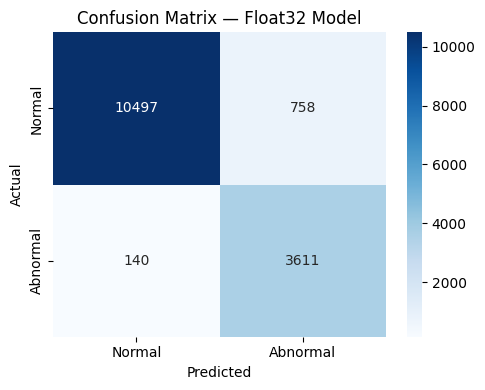

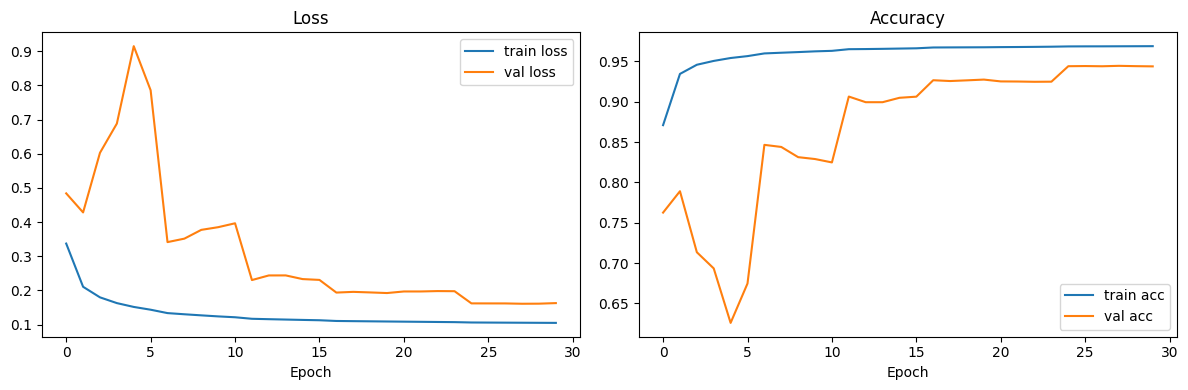

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# §7  EVALUATION
# ─────────────────────────────────────────────────────────────────────────────
print("\nSTEP 5 — Evaluating on held-out test set …")

y_prob  = model.predict(X_test, verbose=0).flatten()   # float probabilities
y_pred  = (y_prob >= 0.5).astype(int)                  # hard labels

print("\nClassification Report (Float32 model):")
print(classification_report(y_test, y_pred, target_names=["Normal", "Abnormal"]))
print(f"AUC-ROC : {roc_auc_score(y_test, y_prob):.4f}")

# ── Confusion matrix plot ─────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Abnormal"],
            yticklabels=["Normal","Abnormal"])
plt.title("Confusion Matrix — Float32 Model")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix_float32.png"), dpi=150)
plt.show()

# ── Training curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"],     label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")
axes[1].plot(history.history["accuracy"],     label="train acc")
axes[1].plot(history.history["val_accuracy"], label="val acc")
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].set_xlabel("Epoch")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_curves.png"), dpi=150)
plt.show()


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# §8  BATCH-NORM FUSION  (fold γ,β,μ,σ into Conv weights)
# ─────────────────────────────────────────────────────────────────────────────
"""
BatchNorm at inference time computes:
    y = gamma * (x - moving_mean) / sqrt(moving_var + eps) + beta

This is a linear operation that can be absorbed into the preceding Conv weights:
    W_fused = W * (gamma / sqrt(moving_var + eps))        # scale each filter
    b_fused =   - moving_mean * (gamma / sqrt(...)) + beta  # offset

After fusion, BN disappears from the graph → no extra hardware.
This is standard practice before deploying to MCUs or FPGAs.
"""
def fold_bn_into_conv(conv_layer, bn_layer):
    """
    Returns (W_fused, b_fused) by folding BatchNorm parameters into Conv weights.
    Works for Conv1D without bias (use_bias=False) followed by BN.

    Parameters
    ----------
    conv_layer : keras Conv1D layer  (use_bias=False)
    bn_layer   : keras BatchNormalization layer immediately after conv_layer

    Returns
    -------
    W_fused : np.ndarray  shape (kernel, in_ch, out_ch)
    b_fused : np.ndarray  shape (out_ch,)
    """
    # Conv weights: shape (kernel_size, in_channels, out_filters)
    W = conv_layer.get_weights()[0]

    # BatchNorm parameters
    gamma      = bn_layer.get_weights()[0]   # learned scale      (out_filters,)
    beta       = bn_layer.get_weights()[1]   # learned shift      (out_filters,)
    mu         = bn_layer.get_weights()[2]   # running mean       (out_filters,)
    var        = bn_layer.get_weights()[3]   # running variance   (out_filters,)
    eps        = bn_layer.epsilon            # numerical stability constant (1e-3)

    # Per-filter scale: how much BN scales each output channel
    std        = np.sqrt(var + eps)          # σ per channel
    scale      = gamma / std                 # γ/σ per channel

    # Fuse: broadcast scale over (kernel, in_ch) dimensions
    # W shape: (k, c_in, c_out) — scale shape: (c_out,) → broadcast to (1,1,c_out)
    W_fused    = W * scale[np.newaxis, np.newaxis, :]

    # Fused bias absorbs the BN mean shift and beta
    b_fused    = beta - mu * scale

    return W_fused, b_fused


print("\nSTEP 6 — Fusing BatchNorm into Conv weights …")
W1_fused, b1_fused = fold_bn_into_conv(model.get_layer("conv1"), model.get_layer("bn1"))
W2_fused, b2_fused = fold_bn_into_conv(model.get_layer("conv2"), model.get_layer("bn2"))
W3 = model.get_layer("classifier").get_weights()[0]   # Dense weights (16, 1)
b3 = model.get_layer("classifier").get_weights()[1]   # Dense bias    (1,)

print(f"  Conv1 fused weights: {W1_fused.shape}   bias: {b1_fused.shape}")
print(f"  Conv2 fused weights: {W2_fused.shape}   bias: {b2_fused.shape}")
print(f"  Dense weights      : {W3.shape}          bias: {b3.shape}")



STEP 6 — Fusing BatchNorm into Conv weights …
  Conv1 fused weights: (7, 1, 8)   bias: (8,)
  Conv2 fused weights: (5, 8, 16)   bias: (16,)
  Dense weights      : (16, 1)          bias: (1,)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# §9  POST-TRAINING QUANTISATION  (Float32 → INT8)
# ─────────────────────────────────────────────────────────────────────────────
"""
QUANTISATION MATH
─────────────────
Goal: represent a float32 weight w ∈ [W_min, W_max] as an int8 integer.

Step 1 — find the absolute-maximum value in the tensor:
    W_absmax = max(|w_i|)   for all elements w_i in the weight tensor

Step 2 — compute a linear scale factor S:
    S = W_absmax / 127          (127 = 2^7 − 1 for signed INT8)
    Interpretation: each INT8 unit represents S float32 units.

Step 3 — quantise (clip to [-127, 127]):
    w_q = round(w / S)  clipped to [-127, 127]

Step 4 — verify (dequantise):
    w_reconstructed = w_q * S   ← approximate original float

Quantisation error:
    The maximum rounding error per weight is ±S/2.
    For shallow networks with small weight ranges (|w| ≤ ~1), this error
    is typically < 0.5% of the weight magnitude — acceptable for ECG classification.

WHY INT8 FOR FPGA?
    - DSP48 slices on Xilinx FPGAs natively perform 18×27-bit signed MACs.
      INT8 operands need only 8-bit paths → 4× DSP sharing possible.
    - LUT-based multipliers for INT8 cost ~4 LUTs vs ~16 LUTs for FP32.
    - BRAM storage: 8-bit weights use ¼ the block-RAM of float32 weights.
"""

def quantize_tensor(tensor: np.ndarray, n_bits: int = 8):
    """
    Symmetric per-tensor linear quantisation.

    Parameters
    ----------
    tensor : float32 numpy array (any shape)
    n_bits : bit-width (default 8)

    Returns
    -------
    q_tensor  : int8  numpy array  — quantised weights
    scale     : float              — S = absmax / (2^(n-1) - 1)
    absmax    : float              — max(|tensor|)
    """
    max_int  = 2 ** (n_bits - 1) - 1              # 127 for INT8
    absmax   = float(np.max(np.abs(tensor)))

    if absmax == 0:
        return np.zeros_like(tensor, dtype=np.int8), 1.0, 0.0

    # Scale factor: ensures absmax maps to max_int (127)
    scale    = absmax / max_int                    # float32 per int unit

    # Divide, round to nearest integer, then clip to valid INT8 range
    q_tensor = np.clip(
        np.round(tensor / scale),
        -max_int, max_int
    ).astype(np.int8)

    return q_tensor, scale, absmax


def dequantize_tensor(q_tensor: np.ndarray, scale: float) -> np.ndarray:
    """
    Reconstruct approximate float32 values from quantised INT8 array.
    Dequant formula: w_approx = w_q × S
    """
    return q_tensor.astype(np.float32) * scale


print("\nSTEP 7 — Quantising weights to INT8 …")

# Quantise each layer's weights (and fused biases)
W1q, S_W1, _ = quantize_tensor(W1_fused, Q_BITS)
b1q, S_b1, _ = quantize_tensor(b1_fused, Q_BITS)

W2q, S_W2, _ = quantize_tensor(W2_fused, Q_BITS)
b2q, S_b2, _ = quantize_tensor(b2_fused, Q_BITS)

W3q, S_W3, _ = quantize_tensor(W3,       Q_BITS)
b3q, S_b3, _ = quantize_tensor(b3,       Q_BITS)

print(f"  Conv1 W  scale: {S_W1:.6f}  |  bias scale: {S_b1:.6f}")
print(f"  Conv2 W  scale: {S_W2:.6f}  |  bias scale: {S_b2:.6f}")
print(f"  Dense W  scale: {S_W3:.6f}  |  bias scale: {S_b3:.6f}")

# ── Per-weight quantisation error ─────────────────────────────────────────
def quant_error(original, q, scale):
    reconstructed = dequantize_tensor(q, scale)
    diff = original.flatten() - reconstructed.flatten()
    return diff.max(), diff.min(), np.abs(diff).mean()

for name, orig, q, s in [
    ("Conv1 W", W1_fused, W1q, S_W1),
    ("Conv2 W", W2_fused, W2q, S_W2),
    ("Dense W", W3,       W3q, S_W3),
]:
    emax, emin, emean = quant_error(orig, q, s)
    print(f"  {name:10s}  max_err={emax:+.6f}  min_err={emin:+.6f}  mean_abs={emean:.6f}")




STEP 7 — Quantising weights to INT8 …
  Conv1 W  scale: 0.017648  |  bias scale: 0.004260
  Conv2 W  scale: 0.072516  |  bias scale: 0.048962
  Dense W  scale: 0.017849  |  bias scale: 0.001008
  Conv1 W     max_err=+0.008340  min_err=-0.008669  mean_abs=0.003766
  Conv2 W     max_err=+0.036155  min_err=-0.036138  mean_abs=0.018487
  Dense W     max_err=+0.008063  min_err=-0.005524  mean_abs=0.003985


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# §10  QUANTISATION ACCURACY EVALUATION
# ─────────────────────────────────────────────────────────────────────────────
"""
We perform a MANUAL forward pass using only quantised (dequantised) weights
to simulate the inference that will run inside the FPGA.

The FPGA will:
  1. Multiply input samples (also INT8) by INT8 weights
  2. Accumulate in INT32 (prevents overflow across 180 multiplications)
  3. Apply scale factors and ReLU
  4. Pass through pooling and GAP
  5. Apply the Dense layer
  6. Apply sigmoid

Here we approximate that by dequantising back to float and running through
numpy — this gives a tight upper bound on accuracy loss.
"""
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def global_average_pool(x):
    # x shape: (timesteps, filters)
    return x.mean(axis=0)   # → (filters,)

def conv1d_numpy(x, W, b, padding="same"):
    """
    Manual 1D convolution for a single sample.

    Parameters
    ----------
    x : (timesteps, in_ch)    — input feature map
    W : (kernel, in_ch, out_ch) — weight tensor
    b : (out_ch,)               — bias vector

    Returns
    -------
    y : (timesteps_out, out_ch)
    """
    T, C_in  = x.shape
    k, _, C_out = W.shape
    pad = k // 2 if padding == "same" else 0

    # Zero-pad the time axis
    x_padded = np.pad(x, ((pad, pad), (0, 0)))

    y = np.zeros((T, C_out), dtype=np.float32)

    for t in range(T):          # each output time step
        for f in range(C_out):  # each output filter
            # Dot product of kernel window with input slice
            y[t, f] = np.sum(x_padded[t:t+k, :] * W[:, :, f]) + b[f]
    return y

def maxpool1d_numpy(x, pool_size=2):
    """
    Non-overlapping max-pooling along the time axis.
    Drops the last partial window if T is odd.
    """
    T, C = x.shape
    T_out = T // pool_size
    y = np.zeros((T_out, C), dtype=np.float32)
    for t in range(T_out):
        y[t] = x[t*pool_size:(t+1)*pool_size, :].max(axis=0)
    return y

def quantized_inference(sample_180x1: np.ndarray) -> float:
    """
    End-to-end forward pass using dequantised INT8 weights.
    Simulates FPGA fixed-point datapath.

    Parameters
    ----------
    sample_180x1 : shape (180, 1)  — one normalised ECG beat

    Returns
    -------
    prob : float  — P(Abnormal)
    """
    # Dequantise all weights once (the FPGA uses stored int8 × scale instead)
    W1d = dequantize_tensor(W1q, S_W1)
    b1d = dequantize_tensor(b1q, S_b1)
    W2d = dequantize_tensor(W2q, S_W2)
    b2d = dequantize_tensor(b2q, S_b2)
    W3d = dequantize_tensor(W3q, S_W3)
    b3d = dequantize_tensor(b3q, S_b3)

    x = sample_180x1.astype(np.float32)              # (180, 1)
    x = relu(conv1d_numpy(x, W1d, b1d))              # (180, 8)
    x = maxpool1d_numpy(x, pool_size=2)              # (90, 8)
    x = relu(conv1d_numpy(x, W2d, b2d))              # (90, 16)
    x = maxpool1d_numpy(x, pool_size=2)              # (45, 16)
    x = global_average_pool(x)                       # (16,)
    logit = np.dot(x, W3d) + b3d                     # scalar
    prob  = float(sigmoid(logit))
    return prob


print("\nSTEP 8 — Running quantised inference on test set …")
print("  (This may take a few minutes — pure-numpy forward pass per sample)")

# Evaluate on first 500 test samples to keep runtime reasonable
N_EVAL = min(500, len(X_test))
y_prob_q  = np.array([quantized_inference(X_test[i]) for i in range(N_EVAL)])
y_pred_q  = (y_prob_q >= 0.5).astype(int)
y_true_q  = y_test[:N_EVAL]

print("\nClassification Report (INT8 quantised model — simulated):")
print(classification_report(y_true_q, y_pred_q, target_names=["Normal", "Abnormal"]))
print(f"AUC-ROC (quantised): {roc_auc_score(y_true_q, y_prob_q):.4f}")

# Accuracy comparison
acc_fp32 = np.mean(y_pred[:N_EVAL]  == y_test[:N_EVAL])
acc_int8 = np.mean(y_pred_q         == y_true_q)
print(f"\n  Float32 accuracy  (first {N_EVAL} samples): {acc_fp32*100:.2f}%")
print(f"  INT8    accuracy  (first {N_EVAL} samples): {acc_int8*100:.2f}%")
print(f"  Accuracy drop due to quantisation         : {(acc_fp32-acc_int8)*100:.2f}%")



STEP 8 — Running quantised inference on test set …
  (This may take a few minutes — pure-numpy forward pass per sample)

Classification Report (INT8 quantised model — simulated):
              precision    recall  f1-score   support

      Normal       0.99      0.90      0.95       375
    Abnormal       0.77      0.98      0.86       125

    accuracy                           0.92       500
   macro avg       0.88      0.94      0.90       500
weighted avg       0.94      0.92      0.92       500

AUC-ROC (quantised): 0.9924

  Float32 accuracy  (first 500 samples): 93.00%
  INT8    accuracy  (first 500 samples): 92.20%
  Accuracy drop due to quantisation         : 0.80%


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# §11  EXPORT FOR VERILOG / FPGA
# ─────────────────────────────────────────────────────────────────────────────
"""
Two export formats:
  A) CSV files       — human-readable; easy to inspect / import into Python
  B) C-style header  — paste directly into Verilog $readmemh or C test bench

The Verilog inference engine will:
  1. Read weights from BRAM initialised from these files
  2. Stream ECG samples from an ADC FIFO (or from a BRAM-stored test window)
  3. Execute the 3-layer CNN datapath using DSP48 MAC chains
  4. Output a 1-bit decision flag (1 = Abnormal beat detected)
"""

# ─── A) CSV export ────────────────────────────────────────────────────────
def save_weights_csv(w_int8: np.ndarray, scale: float, name: str):
    """
    Saves quantised weight tensor to CSV.
    Column 1: flat index, Column 2: int8 value, Column 3: float scale.
    """
    path = os.path.join(OUT_DIR, f"{name}_int8.csv")
    flat = w_int8.flatten()
    with open(path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["flat_index", "int8_value", "scale_factor"])
        for i, v in enumerate(flat):
            writer.writerow([i, int(v), f"{scale:.8f}"])
    print(f"  Saved: {path}  ({len(flat)} elements, scale={scale:.6f})")

print("\nSTEP 9 — Exporting INT8 weights to CSV …")
save_weights_csv(W1q, S_W1, "conv1_weights")
save_weights_csv(b1q, S_b1, "conv1_bias")
save_weights_csv(W2q, S_W2, "conv2_weights")
save_weights_csv(b2q, S_b2, "conv2_bias")
save_weights_csv(W3q, S_W3, "dense_weights")
save_weights_csv(b3q, S_b3, "dense_bias")

# ─── B) C-style header export ─────────────────────────────────────────────
def tensor_to_c_array(w_int8: np.ndarray, scale: float, var_name: str) -> str:
    """
    Formats an INT8 tensor as a C/Verilog-compatible literal array string.

    Example output:
      // scale = 0.00784314
      const int8_t conv1_weights[56] = {
        12, -5, 3, ...
      };
    """
    flat = w_int8.flatten()
    vals = ", ".join(str(int(v)) for v in flat)
    return (
        f"// scale = {scale:.8f}   shape = {list(w_int8.shape)}\n"
        f"const int8_t {var_name}[{len(flat)}] = {{\n"
        f"  {vals}\n}};\n"
    )

c_header_path = os.path.join(OUT_DIR, "ecg_cnn_weights.h")
with open(c_header_path, "w") as fh:
    fh.write("/* Auto-generated by ecg_arrhythmia_classifier.py */\n")
    fh.write("/* ECG 1D-CNN INT8 weights for Verilog/C testbench */\n\n")
    fh.write('#pragma once\n#include <stdint.h>\n\n')
    fh.write("/* ─── Layer scales (multiply INT32 accumulator by scale) ─── */\n")
    fh.write(f"#define SCALE_CONV1_W  {S_W1:.8f}f\n")
    fh.write(f"#define SCALE_CONV1_B  {S_b1:.8f}f\n")
    fh.write(f"#define SCALE_CONV2_W  {S_W2:.8f}f\n")
    fh.write(f"#define SCALE_CONV2_B  {S_b2:.8f}f\n")
    fh.write(f"#define SCALE_DENSE_W  {S_W3:.8f}f\n")
    fh.write(f"#define SCALE_DENSE_B  {S_b3:.8f}f\n\n")
    fh.write("/* ─── Weight arrays (row-major, flat) ─── */\n")
    fh.write(tensor_to_c_array(W1q, S_W1, "conv1_weights") + "\n")
    fh.write(tensor_to_c_array(b1q, S_b1, "conv1_bias")    + "\n")
    fh.write(tensor_to_c_array(W2q, S_W2, "conv2_weights") + "\n")
    fh.write(tensor_to_c_array(b2q, S_b2, "conv2_bias")    + "\n")
    fh.write(tensor_to_c_array(W3q, S_W3, "dense_weights") + "\n")
    fh.write(tensor_to_c_array(b3q, S_b3, "dense_bias")    + "\n")

print(f"\n  Saved C header: {c_header_path}")

# ─── C) Test window CSV (for Verilog stimulus file) ───────────────────────
"""
We export one Normal and one Abnormal beat window as an INT8-quantised CSV
so your Verilog testbench can load them directly into a $readmemh stimulus.
"""
def export_test_window(sample_180x1: np.ndarray, label: int, tag: str):
    """
    Quantises a single 180-sample ECG window to INT8 and saves as CSV.
    The Verilog testbench reads this file into a reg [7:0] window[0:179].
    """
    flat   = sample_180x1.flatten()           # (180,) float32
    absmax = float(np.max(np.abs(flat)))
    scale  = absmax / 127.0
    q      = np.clip(np.round(flat / scale), -127, 127).astype(np.int8)

    path = os.path.join(OUT_DIR, f"test_window_{tag}.csv")
    with open(path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["sample_index", "int8_value", "float_value", "scale"])
        for i, (qi, fi) in enumerate(zip(q, flat)):
            writer.writerow([i, int(qi), f"{fi:.6f}", f"{scale:.8f}"])

    print(f"  Test window ({tag}, label={label}): {path}  scale={scale:.6f}")
    return q, scale


# Find first Normal and Abnormal beat in test set
normal_idx   = np.where(y_test == 0)[0][0]
abnormal_idx = np.where(y_test == 1)[0][0]

print("\nSTEP 10 — Exporting test windows …")
q_normal,   s_normal   = export_test_window(X_test[normal_idx],   0, "normal")
q_abnormal, s_abnormal = export_test_window(X_test[abnormal_idx], 1, "abnormal")

# Verify quantised forward pass on these specific windows
p_normal   = quantized_inference(X_test[normal_idx])
p_abnormal = quantized_inference(X_test[abnormal_idx])
print(f"\n  P(Abnormal | Normal window)   = {p_normal:.4f}  → {'CORRECT ✓' if p_normal < 0.5 else 'WRONG ✗'}")
print(f"  P(Abnormal | Abnormal window) = {p_abnormal:.4f}  → {'CORRECT ✓' if p_abnormal >= 0.5 else 'WRONG ✗'}")




STEP 9 — Exporting INT8 weights to CSV …
  Saved: C:\Users\rishi\OneDrive\Desktop\mitbihcnn\fpga_export/conv1_weights_int8.csv  (56 elements, scale=0.017648)
  Saved: C:\Users\rishi\OneDrive\Desktop\mitbihcnn\fpga_export/conv1_bias_int8.csv  (8 elements, scale=0.004260)
  Saved: C:\Users\rishi\OneDrive\Desktop\mitbihcnn\fpga_export/conv2_weights_int8.csv  (640 elements, scale=0.072516)
  Saved: C:\Users\rishi\OneDrive\Desktop\mitbihcnn\fpga_export/conv2_bias_int8.csv  (16 elements, scale=0.048962)
  Saved: C:\Users\rishi\OneDrive\Desktop\mitbihcnn\fpga_export/dense_weights_int8.csv  (16 elements, scale=0.017849)
  Saved: C:\Users\rishi\OneDrive\Desktop\mitbihcnn\fpga_export/dense_bias_int8.csv  (1 elements, scale=0.001008)

  Saved C header: C:\Users\rishi\OneDrive\Desktop\mitbihcnn\fpga_export/ecg_cnn_weights.h

STEP 10 — Exporting test windows …
  Test window (normal, label=0): C:\Users\rishi\OneDrive\Desktop\mitbihcnn\fpga_export/test_window_normal.csv  scale=0.045363
  Test window

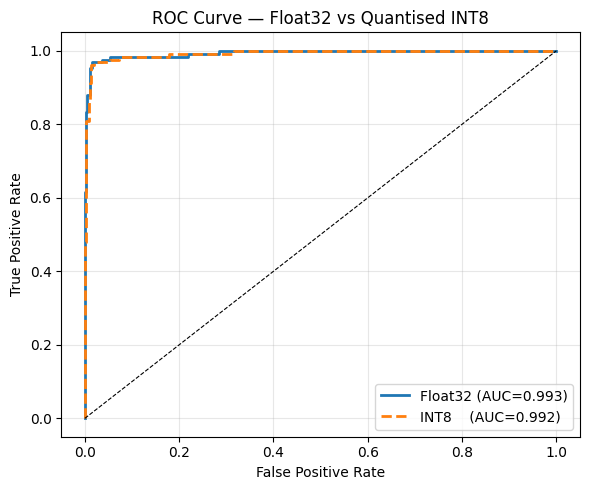

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# §12  ROC CURVE (Float32 vs Quantised overlay)
# ─────────────────────────────────────────────────────────────────────────────
fpr_f, tpr_f, _ = roc_curve(y_test[:N_EVAL], y_prob[:N_EVAL])
fpr_q, tpr_q, _ = roc_curve(y_true_q,        y_prob_q)

auc_f = roc_auc_score(y_test[:N_EVAL], y_prob[:N_EVAL])
auc_q = roc_auc_score(y_true_q,        y_prob_q)

plt.figure(figsize=(6, 5))
plt.plot(fpr_f, tpr_f, label=f"Float32 (AUC={auc_f:.3f})", linewidth=2)
plt.plot(fpr_q, tpr_q, label=f"INT8    (AUC={auc_q:.3f})", linewidth=2, linestyle="--")
plt.plot([0,1],[0,1],"k--", linewidth=0.8)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Float32 vs Quantised INT8")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "roc_curve_comparison.png"), dpi=150)
plt.show()


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# §13  SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("EXPORT SUMMARY")
print("="*60)
print(f"  Output directory    : {OUT_DIR}")
print(f"  Best model (Keras)  : best_model.keras")
print(f"  C header (weights)  : ecg_cnn_weights.h")
print(f"  CSV weights         : conv1/2/dense _weights/bias _int8.csv")
print(f"  Test windows        : test_window_normal/abnormal.csv")
print(f"  Plots               : *.png")
print()
print(f"  Float32 accuracy    : {acc_fp32*100:.2f}%")
print(f"  INT8    accuracy    : {acc_int8*100:.2f}%")
print(f"  Accuracy drop       : {abs(acc_fp32-acc_int8)*100:.2f}%")
print()
print("NEXT STEPS FOR VERILOG RTL:")
print("  1. Initialise BRAMs from ecg_cnn_weights.h using $readmemh")
print("  2. Implement pipelined Conv1D using DSP48 MAC slices")
print("  3. GlobalAveragePool as a running-sum + right-shift divider")
print("  4. Sigmoid approximated as a piecewise-linear LUT (256 entries)")
print("  5. Compare final output against threshold register (default: 64)")
print("="*60)



EXPORT SUMMARY
  Output directory    : C:\Users\rishi\OneDrive\Desktop\mitbihcnn\fpga_export
  Best model (Keras)  : best_model.keras
  C header (weights)  : ecg_cnn_weights.h
  CSV weights         : conv1/2/dense _weights/bias _int8.csv
  Test windows        : test_window_normal/abnormal.csv
  Plots               : *.png

  Float32 accuracy    : 93.00%
  INT8    accuracy    : 92.20%
  Accuracy drop       : 0.80%

NEXT STEPS FOR VERILOG RTL:
  1. Initialise BRAMs from ecg_cnn_weights.h using $readmemh
  2. Implement pipelined Conv1D using DSP48 MAC slices
  3. GlobalAveragePool as a running-sum + right-shift divider
  4. Sigmoid approximated as a piecewise-linear LUT (256 entries)
  5. Compare final output against threshold register (default: 64)
